In [58]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings

In [106]:
df=pd.read_csv("D:\PRO AIML\KAGGLE PROJECTS\HEART DISEASE\heart.csv")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Dell\AppData\Local\Temp\ipykernel_2864\3521458567.py:1: SyntaxWarning: invalid escape sequence '\P'
  df=pd.read_csv("D:\PRO AIML\KAGGLE PROJECTS\HEART DISEASE\heart.csv")


In [107]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [108]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [109]:
x = df.drop(columns=['target'])

In [110]:
x.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [111]:
y=df['target']

In [112]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [113]:
# Create Column Transformer with 3 types of transformers
num_features = x.select_dtypes(exclude="object").columns
cat_features = x.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [114]:
x=preprocessor.fit_transform(x)

In [115]:
x.shape

(1025, 13)

In [116]:
x

array([[-0.26843658,  0.66150409, -0.91575542, ...,  0.99543334,
         1.20922066,  1.08985168],
       [-0.15815703,  0.66150409, -0.91575542, ..., -2.24367514,
        -0.73197147,  1.08985168],
       [ 1.71659547,  0.66150409, -0.91575542, ..., -2.24367514,
        -0.73197147,  1.08985168],
       ...,
       [-0.81983438,  0.66150409, -0.91575542, ..., -0.6241209 ,
         0.23862459, -0.52212231],
       [-0.4889957 , -1.51170646, -0.91575542, ...,  0.99543334,
        -0.73197147, -0.52212231],
       [-0.04787747,  0.66150409, -0.91575542, ..., -0.6241209 ,
         0.23862459,  1.08985168]], shape=(1025, 13))

In [117]:
# separating dataset into train and test
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [118]:
xtrain.shape,ytrain.shape,xtest.shape,ytest.shape

((820, 13), (820,), (205, 13), (205,))

In [119]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [120]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest Classifier": RandomForestClassifier(),
    "XGBoost Classifier": XGBClassifier()
}
model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(xtrain,ytrain)

    ytrainpred=model.predict(xtrain)
    ytestpred=model.predict(xtest)

    #evaluate train and test datasetmodel_train_mae
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(ytrain, ytrainpred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(ytest, ytestpred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.3403
- Mean Absolute Error: 0.2752
- R2 Score: 0.5363
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3842
- Mean Absolute Error: 0.3097
- R2 Score: 0.4096


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.4997
- Mean Absolute Error: 0.4995
- R2 Score: 0.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.5002
- Mean Absolute Error: 0.4999
- R2 Score: -0.0007


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.3403
- Mean Absolute Error: 0.2752
- R2 Score: 0.5363
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3841
- Mean Absolute Error: 0.3096
- R2 Score: 0.4097


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 0.2077
- Mean Absolute Error: 0.0985
- R2 Score: 0.8273
----------------------

In [121]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,CatBoosting Regressor,0.944352
11,XGBoost Classifier,0.941462
4,Decision Tree,0.941462
10,Random Forest Classifier,0.941462
5,Random Forest Regressor,0.940430
6,XGBRegressor,0.939061
3,K-Neighbors Regressor,0.648772
8,AdaBoost Regressor,0.542277
2,Ridge,0.409745
0,Linear Regression,0.409608


In [137]:
catreg=XGBClassifier(verbose=0)
catreg=catreg.fit(xtrain,ytrain)
ypred=catreg.predict(xtest)
score=r2_score(ytest,ypred)*100
print(f"Accuracy is {score}")

Accuracy is 94.14620217018846


d:\PRO AIML\KAGGLE PROJECTS\HEART DISEASE\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:10:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Text(0, 0.5, 'Predicted')

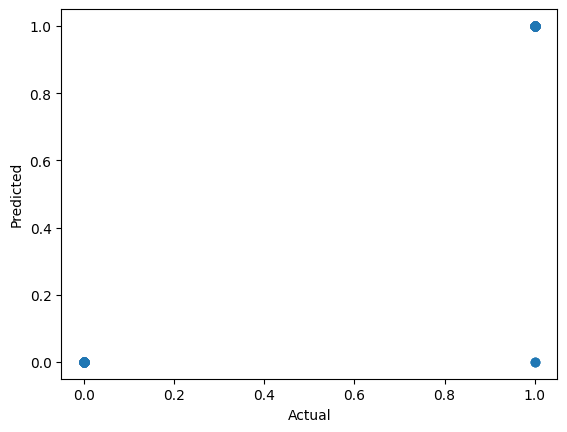

In [138]:
#plotting ypred and ytest graph
plt.scatter(ytest,ypred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [139]:
ytest

527    1
359    1
447    0
31     1
621    0
      ..
832    1
796    1
644    1
404    0
842    0
Name: target, Length: 205, dtype: int64

Text(0, 0.5, 'Predicted')

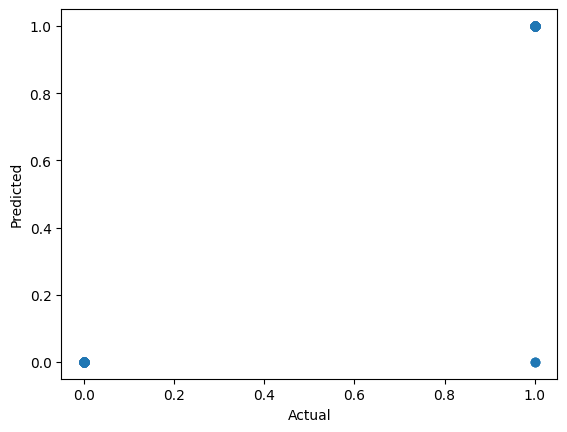

In [141]:
#plotting ypred and ytest graph
plt.scatter(ytest,ypred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

difference between actual and predicted values


In [142]:
pred_df=pd.DataFrame({'Actual Value':ytest,"Predicted value:":ypred, "Difference":ytest-ypred})

In [143]:
pred_df

,Actual Value,Predicted value:,Difference
527,1,1,0
359,1,1,0
447,0,0,0
31,1,1,0
621,0,0,0
...,...,...,...
832,1,1,0
796,1,1,0
644,1,1,0
404,0,0,0
